# 2025 Race Database-Surface EDA

This notebook audits the imported 2025 race-session data surfaces in
Race Telemetry Workbench: session metadata, drivers, weather,
track/session status, race control, circuit markers, raw telemetry
coverage, raw position coverage, ingestion diagnostics, and aligned
10 Hz replay data.

It complements `2025_telemetry_bad_lap_eda.ipynb`, which focuses on
lap-level telemetry shape and bad-lap taxonomy.


## Scope

Race sessions are the default project scope. This notebook is limited
to `year = 2025` and `session_type = 'R'` and refuses to generate
season-level conclusions unless exactly 24 races are present.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "notebooks").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks import database_surface_quality_support as eda
print(f"scope: {eda.SurfaceScope().label}")
print(f"artifact dir: {eda.ARTIFACT_DIR}")


scope: 2025 race sessions
artifact dir: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/2025-race-database-surface-eda


## Installed Skrub API

The EDA uses `skrub.TableReport` for a compact dataframe profile.
`SKB_DATA_DIRECTORY` and the Matplotlib `Agg` backend are configured
by the support module before importing `skrub`.


In [2]:
import inspect
import skrub

print("skrub version:", skrub.__version__)
print("TableReport:", inspect.signature(skrub.TableReport))


skrub version: 0.9.0
TableReport: (dataframe, n_rows=10, order_by=None, title=None, column_filters=None, verbose=None, plot_distributions='auto', compute_associations='auto', open_tab='table', max_plot_columns=None, max_association_columns=None)


## Run The Surface Audit

The support module builds one row per 2025 race session and
supporting tables for ingestion diagnostics, aligned quality flags,
and race-control category mix.


In [3]:
result = eda.run_analysis(write_outputs=True)

classified = result["classified"]
flag_summary = result["flag_summary"]
year_summary = result["year_summary"]
diagnostics = result["diagnostics"]
aligned_flags = result["aligned_flags"]
race_control_categories = result["race_control_categories"]
aligned_races = result["aligned_races"]
aligned_drivers = result["aligned_drivers"]
aligned_laps = result["aligned_laps"]
degraded_segments = result["degraded_segments"]
aligned_windows = result["aligned_windows"]
aligned_context_overlap = result["aligned_context_overlap"]
aligned_lap_context = result["aligned_lap_context"]
desktop_watchlist = result["desktop_watchlist"]
session_duration_coverage = result["session_duration_coverage"]
coverage_windows = result["coverage_windows"]
coverage_summary = result["coverage_summary"]
race_control_messages = result["race_control_messages"]
race_control_taxonomy_summary = result["race_control_taxonomy_summary"]
race_control_duplicates = result["race_control_duplicates"]
race_control_examples = result["race_control_examples"]
status_intervals = result["status_intervals"]
status_race_control_overlap = result["status_race_control_overlap"]
weather_summary = result["weather_summary"]
weather_transitions = result["weather_transitions"]
context_timeline_bins = result["context_timeline_bins"]
context_replay_correlation = result["context_replay_correlation"]
product_readiness = result["product_readiness"]
recommendation_summary = result["recommendation_summary"]
marker_quality = result["marker_quality"]
marker_summary = result["marker_summary"]
marker_position_examples = result["marker_position_examples"]
race_control_clustered = result["race_control_clustered"]
race_control_cluster_summary = result["race_control_cluster_summary"]

print(f"scope: {result['scope'].label}")
print(f"race sessions inspected: {len(classified)}")
print(f"sessions with at least one surface issue: {classified['has_surface_issue'].sum()}")
print(f"summary: {result['summary_path']}")
print(f"skrub report: {result['report_path']}")


scope: 2025 race sessions
race sessions inspected: 24
sessions with at least one surface issue: 24
summary: /Users/fabio/Workspace/race-telemetry-workbench/docs/data-quality/2025-race-database-surface-eda-summary.md
skrub report: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/2025-race-database-surface-eda/skrub_2025_race_database_surface_report.html


## Year-Level Coverage

This table is intentionally single-year. Partial 2024 and 2026 local
imports are excluded from the primary EDA scope.


In [4]:
display(year_summary)
display(classified[['year','event_name','driver_count','lap_rows','telemetry_samples','position_samples','aligned_samples','weather_samples','race_control_messages','corner_markers','surface_issue_count']])


,year,sessions,sessions_with_issue,median_surface_issue_count,telemetry_samples,position_samples,aligned_samples,weather_samples,race_control_messages,issue_pct
0,2025,24,24,2.0,9113457,9314091,24477559,3781,2178,100.0


,year,event_name,driver_count,lap_rows,telemetry_samples,position_samples,aligned_samples,weather_samples,race_control_messages,corner_markers,surface_issue_count
0,2025,Australian Grand Prix,20,927,372477,380930,999583,178,113,14,3
1,2025,Chinese Grand Prix,20,1065,392448,398411,1049027,154,56,16,2
2,2025,Japanese Grand Prix,20,1059,371291,379525,994294,140,23,18,2
3,2025,Bahrain Grand Prix,20,1128,425177,436990,1144940,158,91,15,2
4,2025,Saudi Arabian Grand Prix,20,898,333314,336779,885764,142,65,27,2
5,2025,Miami Grand Prix,20,1005,356089,362855,955079,149,77,19,3
6,2025,Emilia Romagna Grand Prix,20,1207,393149,400409,1055536,150,44,19,2
7,2025,Monaco Grand Prix,20,1425,420152,429303,1131575,160,196,19,2
8,2025,Spanish Grand Prix,19,1203,378908,388975,1019335,155,100,14,2
9,2025,Canadian Grand Prix,20,1349,396025,407524,1069986,167,97,14,2


## Surface Quality Flags

These are session-level flags, not per-lap flags. A session can be
useful for replay and still have a surface flag that deserves
documentation or follow-up.


In [5]:
display(flag_summary)


,surface_flag,sessions,pct_sessions
6,ingestion_diagnostic_warning,24,100.000000
2,lap_metadata_incomplete,18,75.000000
9,race_control_sparse_or_untimed,14,58.333333
5,aligned_replay_quality_issue,0,0.000000
10,circuit_annotation_issue,0,0.000000
1,driver_metadata_sparse,0,0.000000
4,raw_position_coverage_issue,0,0.000000
3,raw_telemetry_coverage_issue,0,0.000000
0,session_metadata_incomplete,0,0.000000
8,status_timeline_sparse,0,0.000000


## Ingestion Diagnostics And Aligned Replay Quality

Raw telemetry coverage and aligned replay quality are different
surfaces. The aligned table can carry quality flags even when raw
streams are present.


In [6]:
display(diagnostics.head(25))
display(aligned_flags.groupby('quality_flag', as_index=False)['rows'].sum().sort_values('rows', ascending=False))


,session_id,year,event_name,driver_code,driver_number,stream_name,sample_count,min_delta_ms,median_delta_ms,p90_delta_ms,p99_delta_ms,max_delta_ms,estimated_frequency_hz,duplicate_count,out_of_order_count,warning_flags
0,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALB,23,raw_car_telemetry,22873,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
1,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALB,23,raw_location_telemetry,23398,20.0,240.0,380.0,520.0,1380.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
2,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALO,14,raw_car_telemetry,13022,158.0,240.0,399.0,481.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
3,2025-australian-grand-prix-r,2025,Australian Grand Prix,ALO,14,raw_location_telemetry,13336,20.0,240.0,380.0,500.0,1340.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
4,2025-australian-grand-prix-r,2025,Australian Grand Prix,ANT,12,raw_car_telemetry,22862,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
5,2025-australian-grand-prix-r,2025,Australian Grand Prix,ANT,12,raw_location_telemetry,23388,20.0,240.0,380.0,520.0,1380.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
6,2025-australian-grand-prix-r,2025,Australian Grand Prix,BEA,87,raw_car_telemetry,22980,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
7,2025-australian-grand-prix-r,2025,Australian Grand Prix,BEA,87,raw_location_telemetry,23505,20.0,240.0,380.0,520.0,1380.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
8,2025-australian-grand-prix-r,2025,Australian Grand Prix,BOR,5,raw_car_telemetry,18661,158.0,240.0,399.0,520.0,1359.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE
9,2025-australian-grand-prix-r,2025,Australian Grand Prix,BOR,5,raw_location_telemetry,19083,20.0,240.0,380.0,520.0,1340.0,4.166667,0,0,SOURCE_GAP_TOO_LARGE


,quality_flag,rows
4,OK,24019401
0,CAR_GAP_TOO_LARGE,262141
2,LOCATION_GAP_TOO_LARGE,231468
1,CAR_SAMPLE_TOO_OLD,140883
3,LOCATION_SAMPLE_TOO_OLD,125959


## Aligned Replay Quality Deep Dive

These tables decode aligned `quality_flags` into stable families and
aggregate them by race, driver, lap, consecutive degraded segment,
and 30-second replay window. The window table is intentionally close
to desktop replay chunks so it can guide warning and overlay design.


In [7]:
display(aligned_races.sort_values('non_ok_pct', ascending=False).head(12))
display(desktop_watchlist.head(20))
display(degraded_segments.head(20))


,session_id,year,event_name,aligned_rows,non_ok_rows,car_gap_rows,car_sample_old_rows,location_gap_rows,location_sample_old_rows,other_unknown_rows,car_related_rows,location_related_rows,non_ok_family_count,non_ok_pct,car_related_pct_of_non_ok,location_related_pct_of_non_ok
0,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,1119107,31300,15265,2447,11119,2469,0,17712,13925,4,2.796873,56.587859,44.488818
5,2025-austrian-grand-prix-r,2025,Austrian Grand Prix,821801,22295,10525,1861,8474,1435,0,12386,10025,4,2.712944,55.555057,44.965239
3,2025-british-grand-prix-r,2025,British Grand Prix,943107,23768,9997,2286,9538,1947,0,12283,11577,4,2.520181,51.678728,48.708347
1,2025-hungarian-grand-prix-r,2025,Hungarian Grand Prix,1134521,27436,12300,2720,10387,2029,0,15020,12456,4,2.418289,54.745590,45.400204
2,2025-belgian-grand-prix-r,2025,Belgian Grand Prix,1035545,24193,9390,2480,10043,2280,0,11870,12603,4,2.336258,49.063779,52.093581
4,2025-monaco-grand-prix-r,2025,Monaco Grand Prix,1131575,23043,14257,3182,4766,838,0,17439,15049,4,2.036365,75.680250,65.308337
6,2025-mexico-city-grand-prix-r,2025,Mexico City Grand Prix,1059385,20890,14466,2519,2733,1172,0,16985,12640,4,1.971899,81.306845,60.507420
19,2025-italian-grand-prix-r,2025,Italian Grand Prix,820417,15478,9731,1816,3492,439,0,11547,10603,4,1.886602,74.602662,68.503683
8,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,1043228,19164,10712,2340,5390,722,0,13052,14016,4,1.836991,68.106867,73.137132
12,2025-miami-grand-prix-r,2025,Miami Grand Prix,955079,17542,10514,2052,4269,707,0,12566,11905,4,1.836707,71.633793,67.865694


,session_id,year,event_name,driver_code,aligned_rows,non_ok_rows,car_gap_rows,car_sample_old_rows,location_gap_rows,location_sample_old_rows,...,location_related_rows,non_ok_pct,longest_segment_ms,segments_over_2s,degraded_windows,severe_windows,windows_with_incident_context,max_window_non_ok_pct,desktop_replay_risk_score,desktop_guidance
353,2025-italian-grand-prix-r,2025,Italian Grand Prix,NOR,44235,841,530,98,189,24,...,575,1.901209,1400,0,62,1,13,37.142857,37.819124,diagnostics_only
47,2025-austrian-grand-prix-r,2025,Austrian Grand Prix,LAW,50953,1385,655,115,526,89,...,622,2.718191,1500,0,111,1,46,30.769231,35.988150,diagnostics_only
390,2025-spanish-grand-prix-r,2025,Spanish Grand Prix,ALO,55987,806,564,92,109,41,...,535,1.439620,1400,0,70,1,56,28.000000,28.658480,diagnostics_only
354,2025-italian-grand-prix-r,2025,Italian Grand Prix,PIA,44256,841,530,98,189,24,...,575,1.900307,1400,0,62,1,13,23.214286,26.672658,diagnostics_only
8,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,STR,59193,1667,813,129,594,131,...,744,2.816211,2000,1,123,3,79,12.000000,24.364846,show_replay_quality_overlay
0,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,ALO,59215,1667,813,129,594,131,...,744,2.815165,2000,1,123,3,79,12.000000,24.360660,show_replay_quality_overlay
9,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,TSU,59234,1667,813,129,594,131,...,744,2.814262,2000,1,123,3,79,12.000000,24.357048,show_replay_quality_overlay
6,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,OCO,59239,1667,813,129,594,131,...,744,2.814025,2000,1,123,3,79,12.000000,24.356098,show_replay_quality_overlay
2,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,COL,59243,1667,813,129,594,131,...,744,2.813835,2000,1,123,3,79,12.000000,24.355338,show_replay_quality_overlay
5,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,LAW,59266,1667,813,129,594,131,...,744,2.812743,2000,1,123,3,79,12.000000,24.350970,show_replay_quality_overlay


,session_id,year,event_name,driver_code,segment_id,start_ms,end_ms,rows,start_lap,end_lap,car_gap_rows,car_sample_old_rows,location_gap_rows,location_sample_old_rows,other_unknown_rows,duration_ms,dominant_family
0,2025-british-grand-prix-r,2025,British Grand Prix,ALB,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
1,2025-british-grand-prix-r,2025,British Grand Prix,ALO,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
2,2025-british-grand-prix-r,2025,British Grand Prix,BEA,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
3,2025-british-grand-prix-r,2025,British Grand Prix,GAS,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
4,2025-british-grand-prix-r,2025,British Grand Prix,HAM,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
5,2025-british-grand-prix-r,2025,British Grand Prix,HUL,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
6,2025-british-grand-prix-r,2025,British Grand Prix,LEC,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
7,2025-british-grand-prix-r,2025,British Grand Prix,NOR,229,8401787,8403987,23,44,44,10,0,13,0,0,2300,location_gap_too_large
8,2025-british-grand-prix-r,2025,British Grand Prix,OCO,229,8401787,8403987,23,43,43,10,0,13,0,0,2300,location_gap_too_large
9,2025-british-grand-prix-r,2025,British Grand Prix,PIA,229,8401787,8403987,23,44,44,10,0,13,0,0,2300,location_gap_too_large


## Context Correlation Checks

This pass checks whether degraded aligned windows overlap
race-control messages or active yellow/SC/VSC/red status intervals.
The result is not causal, but it highlights whether replay-quality
warnings should be explained as source/cadence behavior or as
context-heavy race moments.


In [8]:
display(aligned_context_overlap)
display(aligned_lap_context)

high_context = aligned_windows[
    (aligned_windows['non_ok_pct'] >= result['thresholds'].degraded_window_min_non_ok_pct)
    & aligned_windows['has_incident_context']
].sort_values(['non_ok_pct', 'race_control_messages'], ascending=False)
display(high_context.head(25))


,window_bucket,windows,pct_with_race_control,pct_with_status,pct_with_pit_context,pct_with_incident_context,median_non_ok_pct,p95_non_ok_pct
0,all_windows,82056,13.964853,11.518963,8.166374,21.807059,0.666667,5.333333
1,degraded_windows,37793,14.328050,12.999762,8.628582,23.718678,4.000000,7.666667
2,severe_windows,133,0.000000,27.819549,6.766917,27.819549,11.333333,13.426763


,lap_bucket,laps,laps_with_any_non_ok,laps_with_severe_non_ok,median_non_ok_pct,p95_non_ok_pct,non_ok_rows
0,all_laps,26689,25759,0,1.663468,4.243663,458158
1,pit_laps,1625,1583,0,1.844091,4.251995,35474
2,fastf1_inaccurate_laps,3646,3577,0,1.937817,4.311280,85375
3,missing_lap_time_laps,352,352,0,2.195392,4.372780,13057
4,ordinary_laps,23043,22182,0,1.627034,4.230578,372783


,session_id,year,event_name,driver_code,window_start_ms,window_end_ms,aligned_rows,non_ok_rows,car_gap_rows,car_sample_old_rows,...,incident_like_messages,has_yellow,has_safety_car,has_red_flag,has_vsc,non_ok_pct,has_status_context,has_race_control_context,has_pit_context,has_incident_context
30825,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,ALB,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
31023,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,ALO,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
31221,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,ANT,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
31419,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,BEA,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
31617,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,BOR,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
31815,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,COL,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
32013,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,GAS,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
32211,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,HAD,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
32471,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,HUL,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True
32669,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,LAW,5340000,5370000,300,36,13,0,...,0,False,True,False,False,12.000000,True,False,False,True


## Session Duration And Coverage Windows

`session_end_utc` is still missing in the imported session metadata,
so this section derives duration from the imported sample and status
surfaces. It also separates the full session timeline from the active
replay window that matters most to desktop playback.


In [9]:
display(session_duration_coverage[[
    'event_name',
    'derived_session_duration_ms',
    'duration_source',
    'active_replay_start_ms',
    'active_replay_end_ms',
    'active_replay_duration_ms',
    'finished_to_derived_end_gap_ms',
]])
display(coverage_summary)
display(coverage_windows.sort_values(['active_coverage_ratio', 'surface']).head(25))


,event_name,derived_session_duration_ms,duration_source,active_replay_start_ms,active_replay_end_ms,active_replay_duration_ms,finished_to_derived_end_gap_ms
0,Australian Grand Prix,10632748,session_status_finished,4260581,10426981,6166400,0
1,Chinese Grand Prix,9243467,session_status_finished,3543065,9079065,5536000,0
2,Japanese Grand Prix,8495802,session_status_finished,3366970,8377670,5010700,0
3,Bahrain Grand Prix,9913997,session_status_finished,3334933,9141033,5806100,0
4,Saudi Arabian Grand Prix,8490361,session_status_finished,3417386,8383386,4966000,0
5,Miami Grand Prix,8957990,session_status_finished,3435459,8857359,5421900,0
6,Emilia Romagna Grand Prix,9001103,session_status_finished,3359385,8891085,5531700,0
7,Monaco Grand Prix,9560014,session_status_finished,3368914,9474614,6105700,0
8,Spanish Grand Prix,9494399,session_status_finished,3553802,9163002,5609200,0
9,Canadian Grand Prix,10394423,session_status_finished,3479645,9007545,5527900,0


,surface,sessions,median_coverage_ratio,median_active_coverage_ratio,min_active_coverage_ratio,sessions_starting_after_active,sessions_ending_before_active_end
0,raw telemetry,24,0.591998,1.000000,1.000000,0,0
1,raw position,24,0.592002,0.415679,0.274514,0,24
2,aligned replay,24,0.591973,1.000000,1.000000,0,0
3,weather,24,0.990176,1.000000,0.995103,0,0
4,track status,24,0.740655,0.615276,0.000000,0,20
5,session status,24,0.999171,1.000000,1.000000,0,0
6,race control,24,0.630772,0.454820,0.317823,0,24


,session_id,year,event_name,surface,surface_key,start_ms,end_ms,span_ms,derived_session_duration_ms,active_replay_start_ms,active_replay_end_ms,active_replay_duration_ms,coverage_ratio,active_coverage_ratio,starts_after_active_ms,ends_before_active_end_ms
18,2025-japanese-grand-prix-r,2025,Japanese Grand Prix,track status,track_status,0,0,0,8495802,3366970,8377670,5010700,0.000000,0.000000,-3366970,8377670
95,2025-hungarian-grand-prix-r,2025,Hungarian Grand Prix,track status,track_status,0,2547920,2547920,9412940,3468106,9261406,5793300,0.270683,0.000000,-3468106,6713486
165,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,track status,track_status,0,2812088,2812088,9280200,3501037,8753137,5252100,0.303020,0.000000,-3501037,5941049
32,2025-saudi-arabian-grand-prix-r,2025,Saudi Arabian Grand Prix,track status,track_status,8569,3847987,3839418,8490361,3417386,8383386,4966000,0.452209,0.086710,-3408817,4535399
11,2025-chinese-grand-prix-r,2025,Chinese Grand Prix,track status,track_status,0,4113507,4113507,9243467,3543065,9079065,5536000,0.445018,0.103042,-3543065,4965558
88,2025-belgian-grand-prix-r,2025,Belgian Grand Prix,track status,track_status,0,8765268,8765268,13458265,8072330,13289930,5217600,0.651293,0.132808,-8072330,4524662
144,2025-s-o-paulo-grand-prix-r,2025,São Paulo Grand Prix,track status,track_status,0,4219151,4219151,9158888,3414801,9005301,5590500,0.460662,0.143878,-3414801,4786150
158,2025-qatar-grand-prix-r,2025,Qatar Grand Prix,track status,track_status,0,4563334,4563334,8985803,3521625,8684625,5163000,0.507838,0.201764,-3521625,4121291
106,2025-italian-grand-prix-r,2025,Italian Grand Prix,raw position,position,214934,4701696,4486762,8652942,3470087,7956587,4486500,0.518524,0.274514,-3255153,3254891
111,2025-italian-grand-prix-r,2025,Italian Grand Prix,race control,race_control,215000,4896000,4681000,8652942,3470087,7956587,4486500,0.540972,0.317823,-3255087,3060587


## Race-Control, Status, And Weather Context

This pass turns imported context rows into deterministic buckets that
can drive desktop timeline chips and filters: race-control taxonomy,
repeated message groups, track-status intervals, weather cadence and
rainfall transitions, plus a 5-minute context-density table.


In [10]:
display(race_control_taxonomy_summary)
display(race_control_duplicates.head(20))
display(race_control_examples)
display(status_race_control_overlap.sort_values(['incident_messages', 'race_control_messages'], ascending=False).head(25))
display(weather_summary.sort_values(['large_gap_flag', 'rainfall_transitions', 'max_gap_ms'], ascending=[False, False, False]).head(20))
display(weather_transitions)
display(context_replay_correlation)
display(context_timeline_bins.sort_values(['degraded_window_rate', 'incident_messages'], ascending=False).head(25))


,taxonomy,messages,missing_session_time,missing_lap_scope,missing_driver_scope,driver_scoped,lap_scoped,sessions,missing_session_time_pct,missing_lap_scope_pct,missing_driver_scope_pct,driver_scoped_pct,lap_scoped_pct
1,flags,1008,146,0,501,507,1008,24,14.484127,0.0,49.702381,50.297619,100.0
3,other,431,47,0,431,0,431,24,10.904872,0.0,100.000000,0.000000,100.0
2,investigations_noted,318,25,0,318,0,318,23,7.861635,0.0,100.000000,0.000000,100.0
0,drs,139,68,0,139,0,139,24,48.920863,0.0,100.000000,0.000000,100.0
7,safety_car,92,2,0,92,0,92,18,2.173913,0.0,100.000000,0.000000,100.0
5,pit_entry_exit,89,48,0,89,0,89,24,53.932584,0.0,100.000000,0.000000,100.0
4,penalties,76,0,0,76,0,76,19,0.000000,0.0,100.000000,0.000000,100.0
6,red_flag,25,0,0,25,0,25,24,0.000000,0.0,100.000000,0.000000,100.0


,session_id,event_name,normalized_message,messages,first_session_time_ms,last_session_time_ms,taxonomy,example_message,span_ms
297,2025-belgian-grand-prix-r,Belgian Grand Prix,clear in track sector #,39,3376000.0,10186000.0,flags,CLEAR IN TRACK SECTOR 4,6810000.0
327,2025-british-grand-prix-r,British Grand Prix,clear in track sector #,37,279000.0,5474000.0,flags,CLEAR IN TRACK SECTOR 5,5195000.0
366,2025-british-grand-prix-r,British Grand Prix,yellow in track sector #,32,263000.0,5291000.0,flags,YELLOW IN TRACK SECTOR 5,5028000.0
298,2025-belgian-grand-prix-r,Belgian Grand Prix,double yellow in track sector #,22,3346000.0,10139000.0,flags,DOUBLE YELLOW IN TRACK SECTOR 4,6793000.0
88,2025-australian-grand-prix-r,Australian Grand Prix,clear in track sector #,20,317000.0,6420000.0,flags,CLEAR IN TRACK SECTOR 2,6103000.0
823,2025-monaco-grand-prix-r,Monaco Grand Prix,waved blue flag for car # (hul) timed at #:#:#,18,2423000.0,5295000.0,flags,WAVED BLUE FLAG FOR CAR 27 (HUL) TIMED AT 15:4...,2872000.0
459,2025-dutch-grand-prix-r,Dutch Grand Prix,double yellow in track sector #,18,1907000.0,6810000.0,flags,DOUBLE YELLOW IN TRACK SECTOR 5,4903000.0
819,2025-monaco-grand-prix-r,Monaco Grand Prix,waved blue flag for car # (bea) timed at #:#:#,15,2276000.0,5611000.0,flags,WAVED BLUE FLAG FOR CAR 87 (BEA) TIMED AT 15:3...,3335000.0
191,2025-azerbaijan-grand-prix-r,Azerbaijan Grand Prix,clear in track sector #,14,636000.0,6175000.0,flags,CLEAR IN TRACK SECTOR 6,5539000.0
192,2025-azerbaijan-grand-prix-r,Azerbaijan Grand Prix,double yellow in track sector #,14,293000.0,6153000.0,flags,DOUBLE YELLOW IN TRACK SECTOR 7,5860000.0


,taxonomy,event_name,session_time_ms,lap_number,driver_code,category,flag,scope,message
0,drs,Canadian Grand Prix,267000.0,2,None,Drs,None,None,DRS ENABLED
1,drs,Hungarian Grand Prix,274000.0,2,None,Drs,None,None,DRS ENABLED
2,drs,Dutch Grand Prix,280000.0,2,None,Drs,None,None,DRS ENABLED
3,drs,Spanish Grand Prix,281000.0,2,None,Drs,None,None,DRS ENABLED
4,drs,Abu Dhabi Grand Prix,307000.0,2,None,Drs,None,None,DRS ENABLED
5,flags,Australian Grand Prix,59000.0,1,None,Flag,DOUBLE YELLOW,Sector,DOUBLE YELLOW IN TRACK SECTOR 2
6,flags,Austrian Grand Prix,91000.0,1,None,Flag,YELLOW,Sector,YELLOW IN TRACK SECTOR 16
7,flags,Austrian Grand Prix,101000.0,1,None,Flag,CLEAR,Sector,CLEAR IN TRACK SECTOR 16
8,flags,Miami Grand Prix,236000.0,1,None,Flag,DOUBLE YELLOW,Sector,DOUBLE YELLOW IN TRACK SECTOR 2
9,flags,Monaco Grand Prix,241000.0,1,None,Flag,YELLOW,Sector,YELLOW IN TRACK SECTOR 10


,session_id,event_name,status_label,start_ms,end_ms,duration_ms,race_control_messages,incident_messages,taxonomies
91,2025-spanish-grand-prix-r,Spanish Grand Prix,clear,712805,7962315.0,7249510.0,92,78,"drs,flags,investigations_noted,other,penalties..."
99,2025-canadian-grand-prix-r,Canadian Grand Prix,clear,392909,7158892.0,6765983.0,89,75,"drs,flags,investigations_noted,other,penalties..."
235,2025-singapore-grand-prix-r,Singapore Grand Prix,clear,3982255,7613749.0,3631494.0,87,64,"drs,flags,investigations_noted,other,pit_entry..."
74,2025-monaco-grand-prix-r,Monaco Grand Prix,clear,1475108,3420403.0,1945295.0,66,64,"flags,other"
81,2025-monaco-grand-prix-r,Monaco Grand Prix,clear,4298677,6354608.0,2055931.0,70,63,"flags,investigations_noted,other,penalties,red..."
177,2025-hungarian-grand-prix-r,Hungarian Grand Prix,clear,2547920,9412940.0,6865020.0,66,56,"flags,investigations_noted,other,penalties,pit..."
156,2025-belgian-grand-prix-r,Belgian Grand Prix,red_flag,3390244,6562639.0,3172395.0,62,49,"drs,flags,other,pit_entry_exit,safety_car"
114,2025-austrian-grand-prix-r,Austrian Grand Prix,clear,4569488,6509248.0,1939760.0,54,46,"drs,flags,investigations_noted,other,penalties..."
35,2025-bahrain-grand-prix-r,Bahrain Grand Prix,clear,0,6475160.0,6475160.0,83,39,"drs,flags,investigations_noted,other,penalties..."
11,2025-australian-grand-prix-r,Australian Grand Prix,clear,5270163,7646655.0,2376492.0,46,37,"drs,flags,investigations_noted,other,penalties..."


,session_id,year,event_name,samples,start_ms,end_ms,median_gap_ms,p95_gap_ms,max_gap_ms,max_air_temp_delta_c,...,max_pressure_delta_mbar,max_wind_speed_delta_mps,max_wind_direction_delta_deg,rainfall_samples,rainfall_transitions,large_gap_flag,temperature_jump_flag,pressure_jump_flag,humidity_jump_flag,wind_jump_flag
1,2025-australian-grand-prix-r,2025,Australian Grand Prix,178,7776,10629022,60004.0,60038.00,60092.0,0.3,...,0.5,3.6,166.0,58,17,False,False,False,False,True
5,2025-belgian-grand-prix-r,2025,Belgian Grand Prix,223,36172,13357618,60005.0,60032.00,60200.0,0.3,...,0.2,1.6,178.0,102,12,False,False,False,False,True
6,2025-british-grand-prix-r,2025,British Grand Prix,155,19723,9260295,60003.0,60026.05,60220.0,0.4,...,0.2,2.7,180.0,28,4,False,False,False,False,True
16,2025-miami-grand-prix-r,2025,Miami Grand Prix,149,17964,8898989,60006.0,60029.65,60046.0,0.2,...,0.3,1.3,171.0,5,4,False,False,False,False,True
21,2025-singapore-grand-prix-r,2025,Singapore Grand Prix,161,38510,9639692,60007.5,60033.05,60040.0,0.2,...,0.2,0.8,154.0,6,4,False,False,False,False,True
7,2025-canadian-grand-prix-r,2025,Canadian Grand Prix,167,34453,9995075,60001.0,60018.75,60032.0,0.3,...,0.2,1.8,180.0,1,2,False,False,False,False,True
0,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,154,60108,9240886,60003.0,60021.40,60224.0,0.1,...,0.2,1.6,180.0,0,0,False,False,False,False,True
14,2025-las-vegas-grand-prix-r,2025,Las Vegas Grand Prix,141,6103,8406722,60003.0,60026.05,60140.0,0.1,...,0.2,1.1,179.0,0,0,False,False,False,False,True
4,2025-bahrain-grand-prix-r,2025,Bahrain Grand Prix,158,14542,9435360,60004.0,60030.00,60137.0,0.1,...,0.2,1.5,153.0,0,0,False,False,False,False,True
19,2025-s-o-paulo-grand-prix-r,2025,São Paulo Grand Prix,152,61035,9121811,60003.0,60023.00,60127.0,0.2,...,0.2,1.6,174.0,0,0,False,False,False,False,True


,session_id,year,event_name,session_time_ms,rainfall,air_temp_c,track_temp_c,humidity_pct,pressure_mbar
9,2025-australian-grand-prix-r,2025,Australian Grand Prix,547785,False,15.6,18.7,89.0,1009.1
24,2025-australian-grand-prix-r,2025,Australian Grand Prix,1447858,True,15.5,18.7,86.0,1009.2
32,2025-australian-grand-prix-r,2025,Australian Grand Prix,1927922,False,15.1,18.5,87.0,1009.8
34,2025-australian-grand-prix-r,2025,Australian Grand Prix,2047926,True,15.1,18.5,87.0,1009.6
42,2025-australian-grand-prix-r,2025,Australian Grand Prix,2527971,False,15.2,18.3,87.0,1009.2
74,2025-australian-grand-prix-r,2025,Australian Grand Prix,4448204,True,15.8,19.2,75.0,1010.0
76,2025-australian-grand-prix-r,2025,Australian Grand Prix,4568255,False,15.8,19.2,76.0,1009.9
77,2025-australian-grand-prix-r,2025,Australian Grand Prix,4628247,True,15.8,19.2,75.0,1010.0
83,2025-australian-grand-prix-r,2025,Australian Grand Prix,4988292,False,15.8,19.0,76.0,1009.9
98,2025-australian-grand-prix-r,2025,Australian Grand Prix,5888397,True,16.0,19.3,74.0,1010.1


,bin_bucket,bins,median_degraded_window_rate,p95_degraded_window_rate,median_max_non_ok_pct,p95_max_non_ok_pct,severe_driver_windows
0,all_bins,466,50.000000,78.517615,4.666667,9.000000,133
1,context_event_bins,225,50.000000,80.000000,5.000000,9.000000,97
2,no_context_event_bins,241,40.880503,70.000000,4.666667,9.000000,36
3,race_control_incident_bins,168,50.000000,80.000000,5.000000,8.666667,58
4,status_bins,96,50.000000,82.500000,5.000000,9.833333,78
5,rainfall_transition_bins,15,40.000000,72.000000,6.666667,8.966667,0


,session_id,year,event_name,bin_start_ms,driver_windows,degraded_driver_windows,severe_driver_windows,max_non_ok_pct,race_control_messages,incident_messages,...,vsc_messages,penalty_messages,rainfall_transitions,has_yellow,has_safety_car,has_red_flag,has_vsc,has_status_context,has_context_event,degraded_window_rate
123,2025-british-grand-prix-r,2025,British Grand Prix,5100000,170,170,0,7.333333,19,11,...,0,1,1,False,True,False,False,True,True,100.000000
157,2025-chinese-grand-prix-r,2025,Chinese Grand Prix,3300000,40,40,0,4.666667,0,0,...,0,0,0,True,False,False,False,True,True,100.000000
40,2025-austrian-grand-prix-r,2025,Austrian Grand Prix,4200000,144,142,0,7.000000,4,4,...,0,0,0,True,True,False,False,True,True,98.611111
18,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,8700000,23,22,2,13.924051,0,0,...,0,0,0,False,False,False,False,False,False,95.652174
182,2025-dutch-grand-prix-r,2025,Dutch Grand Prix,4800000,200,180,20,12.000000,3,2,...,0,0,0,True,False,False,False,True,True,90.000000
56,2025-austrian-grand-prix-r,2025,Austrian Grand Prix,9000000,160,144,0,8.333333,0,0,...,0,0,0,False,False,False,False,False,False,90.000000
102,2025-belgian-grand-prix-r,2025,Belgian Grand Prix,9000000,200,180,0,6.333333,0,0,...,0,0,0,False,False,False,False,False,False,90.000000
118,2025-british-grand-prix-r,2025,British Grand Prix,3600000,180,162,18,10.333333,0,0,...,0,0,0,True,False,False,True,True,True,90.000000
228,2025-hungarian-grand-prix-r,2025,Hungarian Grand Prix,6600000,200,180,0,8.000000,0,0,...,0,0,0,False,False,False,False,False,False,90.000000
366,2025-qatar-grand-prix-r,2025,Qatar Grand Prix,8400000,144,117,0,7.936508,0,0,...,0,0,0,False,False,False,False,False,False,81.250000


## Product Readiness And Recommendations

The EDA now turns inventory and severity signals into five product
lenses: catalog, raw streams, replay, context, and circuit context.
The final recommendation column maps analysis into API/desktop
decisions: no action, label in UI, inspect, reimport, or
schema/importer change.


In [11]:
display(recommendation_summary)
display(product_readiness[[
    'event_name',
    'catalog_readiness',
    'raw_stream_readiness',
    'replay_readiness',
    'context_readiness',
    'circuit_context_readiness',
    'final_recommendation',
    'schema_importer_follow_up',
    'affected_drivers',
    'affected_replay_windows',
    'marker_coordinate_issues',
    'product_impact',
    'systematic_known_limitations',
]])


,final_recommendation,sessions,max_readiness_score,affected_drivers,affected_rows,severe_replay_windows,marker_coordinate_issues,schema_importer_follow_up_sessions
0,no_action,0,0,0,0,0,0,0
1,label_in_ui,24,2,476,458158,133,0,24
2,inspect,0,0,0,0,0,0,0
3,reimport,0,0,0,0,0,0,0
4,schema_importer_change,0,0,0,0,0,0,0


,event_name,catalog_readiness,raw_stream_readiness,replay_readiness,context_readiness,circuit_context_readiness,final_recommendation,schema_importer_follow_up,affected_drivers,affected_replay_windows,marker_coordinate_issues,product_impact,systematic_known_limitations
0,Australian Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,label_in_ui,True,20,1507,0,launcher; bounded raw API/MCP; desktop replay;...,session_end_utc missing; position coverage app...
1,Chinese Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,label_in_ui,True,20,1454,0,launcher; bounded raw API/MCP; desktop replay;...,session_end_utc missing; position coverage app...
2,Japanese Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,label_in_ui,True,20,1419,0,launcher; bounded raw API/MCP; desktop replay;...,session_end_utc missing; position coverage app...
3,Bahrain Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,ready,label_in_ui,True,20,1512,0,launcher; bounded raw API/MCP; desktop replay,session_end_utc missing; position coverage app...
4,Saudi Arabian Grand Prix,ready_with_warnings,ready_with_warnings,partial,ready,ready,label_in_ui,True,20,1253,0,launcher; bounded raw API/MCP; desktop replay,session_end_utc missing; position coverage app...
5,Miami Grand Prix,ready_with_warnings,ready_with_warnings,partial,ready_with_warnings,ready,label_in_ui,True,20,1427,0,launcher; bounded raw API/MCP; desktop replay;...,session_end_utc missing; position coverage app...
6,Emilia Romagna Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,ready,label_in_ui,True,20,1398,0,launcher; bounded raw API/MCP; desktop replay,session_end_utc missing; position coverage app...
7,Monaco Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,ready,label_in_ui,True,20,1764,0,launcher; bounded raw API/MCP; desktop replay,session_end_utc missing; position coverage app...
8,Spanish Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,ready,label_in_ui,True,19,1252,0,launcher; bounded raw API/MCP; desktop replay,session_end_utc missing; position coverage app...
9,Canadian Grand Prix,ready_with_warnings,ready_with_warnings,ready_with_warnings,ready,ready,label_in_ui,True,20,1636,0,launcher; bounded raw API/MCP; desktop replay,session_end_utc missing; position coverage app...


## Circuit Marker Geometry QA

Marker coordinates are compared against imported position trace
bounds. Markers outside padded min/max bounds are treated as
implausible; markers outside the core percentile trace are marked
for inspection before desktop callouts rely on them.


In [12]:
display(marker_summary)
display(marker_quality[marker_quality['marker_coordinate_issue'] != 'none'][[
    'event_name',
    'marker_type',
    'marker_number',
    'marker_letter',
    'x',
    'y',
    'marker_coordinate_issue',
    'outside_minmax_bounds',
    'outside_core_bounds',
]].head(40))
display(marker_position_examples.groupby(['event_name', 'driver_code']).size().reset_index(name='sampled_trace_points'))


,session_id,year,event_name,circuit_metadata_present,rotation_present,position_xy_samples,position_driver_count,marker_count,corner_markers,marshal_light_markers,marshal_sector_markers,marker_distance_nulls,markers_outside_position_bounds,markers_outside_core_bounds,circuit_context_readiness,circuit_context_recommendation
0,2025-australian-grand-prix-r,2025,Australian Grand Prix,True,True,380930,20,54,14,20,20,0,0,0,ready,no_action
1,2025-chinese-grand-prix-r,2025,Chinese Grand Prix,True,True,398411,20,56,16,20,20,0,0,0,ready,no_action
2,2025-japanese-grand-prix-r,2025,Japanese Grand Prix,True,True,379525,20,62,18,22,22,0,0,0,ready,no_action
3,2025-bahrain-grand-prix-r,2025,Bahrain Grand Prix,True,True,436990,20,51,15,18,18,0,0,0,ready,no_action
4,2025-saudi-arabian-grand-prix-r,2025,Saudi Arabian Grand Prix,True,True,336779,20,69,27,21,21,0,0,0,ready,no_action
5,2025-miami-grand-prix-r,2025,Miami Grand Prix,True,True,362855,20,58,19,19,20,0,0,0,ready,no_action
6,2025-emilia-romagna-grand-prix-r,2025,Emilia Romagna Grand Prix,True,True,400409,20,57,19,19,19,0,0,0,ready,no_action
7,2025-monaco-grand-prix-r,2025,Monaco Grand Prix,True,True,429303,20,57,19,19,19,0,0,0,ready,no_action
8,2025-spanish-grand-prix-r,2025,Spanish Grand Prix,True,True,388975,19,46,14,16,16,0,0,0,ready,no_action
9,2025-canadian-grand-prix-r,2025,Canadian Grand Prix,True,True,407524,20,44,14,15,15,0,0,0,ready,no_action


,event_name,marker_type,marker_number,marker_letter,x,y,marker_coordinate_issue,outside_minmax_bounds,outside_core_bounds


,event_name,driver_code,sampled_trace_points
0,Abu Dhabi Grand Prix,ALB,2486
1,Australian Grand Prix,BEA,2352
2,Azerbaijan Grand Prix,STR,2380
3,Bahrain Grand Prix,BOR,2463
4,Belgian Grand Prix,COL,2486
5,British Grand Prix,LEC,2257


## Race-Control Text Clusters And Weather Trend Panels

Text clustering complements the deterministic taxonomy by surfacing
repeated phrase families. Weather trend panels show races with
rainfall or large shifts so the desktop context strip can be tested
against real changes.


In [13]:
display(race_control_cluster_summary)
display(race_control_clustered[[
    'event_name',
    'session_time_ms',
    'taxonomy',
    'text_cluster',
    'cluster_terms',
    'message',
]].head(40))


,text_cluster,cluster_terms,messages,sessions,taxonomy_mix,driver_scoped_pct,lap_scoped_pct,example_message,cluster_method
3,3,"blue flag, waved, timed, waved blue, blue, fla...",480,23,"flags,red_flag",99.791667,100.0,WAVED BLUE FLAG FOR CAR 87 (BEA) TIMED AT 16:0...,tfidf_kmeans
0,0,"car, safety car, safety, involving car, penalt...",405,24,"drs,flags,investigations_noted,other,penalties...",6.913580,100.0,ABORTED START,tfidf_kmeans
4,4,"lap, turn lap, deleted track, deleted, limits ...",324,23,other,0.000000,100.0,CAR 12 (ANT) TIME 1:37.326 DELETED - TRACK LIM...,tfidf_kmeans
1,1,"clear, clear track, sector, track sector, trac...",255,23,flags,0.000000,100.0,CLEAR IN TRACK SECTOR 2,tfidf_kmeans
5,5,"yellow track, yellow, sector, track sector, do...",245,23,flags,0.000000,100.0,DOUBLE YELLOW IN TRACK SECTOR 2,tfidf_kmeans
7,7,"turn incident, involving cars, cars, incident,...",217,23,"investigations_noted,safety_car",0.000000,100.0,INCIDENT INVOLVING CARS 5 (BOR) AND 30 (LAW) N...,tfidf_kmeans
2,2,"drs enabled, enabled, drs, enabled zone, zone,...",74,24,drs,0.000000,100.0,DRS ENABLED,tfidf_kmeans
6,6,"pit exit, exit, pit, green light, green, light...",72,24,pit_entry_exit,0.000000,100.0,GREEN LIGHT - PIT EXIT OPEN,tfidf_kmeans
8,8,"drs disabled, disabled, drs, disabled zone, zo...",63,24,drs,0.000000,100.0,DRS DISABLED IN ZONE 3,tfidf_kmeans
9,9,"slippery track, slippery, surface slippery, su...",43,13,other,0.000000,100.0,TRACK SURFACE SLIPPERY IN TRACK SECTOR 15,tfidf_kmeans


,event_name,session_time_ms,taxonomy,text_cluster,cluster_terms,message
0,Australian Grand Prix,59000.0,flags,5,"yellow track, yellow, sector, track sector, do...",DOUBLE YELLOW IN TRACK SECTOR 2
1,Australian Grand Prix,137000.0,other,0,"car, safety car, safety, involving car, penalt...",ABORTED START
2,Australian Grand Prix,255000.0,other,0,"car, safety car, safety, involving car, penalt...",FORMATION LAP WILL START AT 15:15
3,Australian Grand Prix,317000.0,flags,1,"clear, clear track, sector, track sector, trac...",CLEAR IN TRACK SECTOR 2
4,Australian Grand Prix,1103000.0,pit_entry_exit,6,"pit exit, exit, pit, green light, green, light...",GREEN LIGHT - PIT EXIT OPEN
5,Australian Grand Prix,1167000.0,flags,5,"yellow track, yellow, sector, track sector, do...",DOUBLE YELLOW IN TRACK SECTOR 8
6,Australian Grand Prix,1171000.0,safety_car,0,"car, safety car, safety, involving car, penalt...",SAFETY CAR DEPLOYED
7,Australian Grand Prix,1218000.0,flags,5,"yellow track, yellow, sector, track sector, do...",DOUBLE YELLOW IN TRACK SECTOR 8
8,Australian Grand Prix,1258000.0,flags,5,"yellow track, yellow, sector, track sector, do...",DOUBLE YELLOW IN TRACK SECTOR 20
9,Australian Grand Prix,1282000.0,safety_car,0,"car, safety car, safety, involving car, penalt...",SAFETY CAR THROUGH THE PIT LANE


## Race-Control Message Mix

Race-control messages are a storytelling surface. This table checks
category/scope distribution and timing completeness before any
incident taxonomy work.


In [14]:
display(race_control_categories.head(50))


,session_id,year,event_name,category,flag,scope,messages,missing_session_time,lap_scoped,driver_scoped
0,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Other,missing,missing,84,4,84,0
1,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,BLUE,Driver,9,0,9,9
2,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,BLACK AND WHITE,Driver,7,0,7,7
3,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Drs,missing,missing,2,1,2,0
4,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,GREEN,Track,2,1,2,0
5,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,CLEAR,Sector,1,1,1,0
6,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,DOUBLE YELLOW,Sector,1,1,1,0
7,2025-abu-dhabi-grand-prix-r,2025,Abu Dhabi Grand Prix,Flag,CHEQUERED,Track,1,0,1,0
8,2025-australian-grand-prix-r,2025,Australian Grand Prix,Other,missing,missing,45,3,45,0
9,2025-australian-grand-prix-r,2025,Australian Grand Prix,Flag,CLEAR,Sector,20,4,20,0


## Visual Artifacts


artifacts/2025-race-database-surface-eda/figures/surface_availability_heatmap.svg


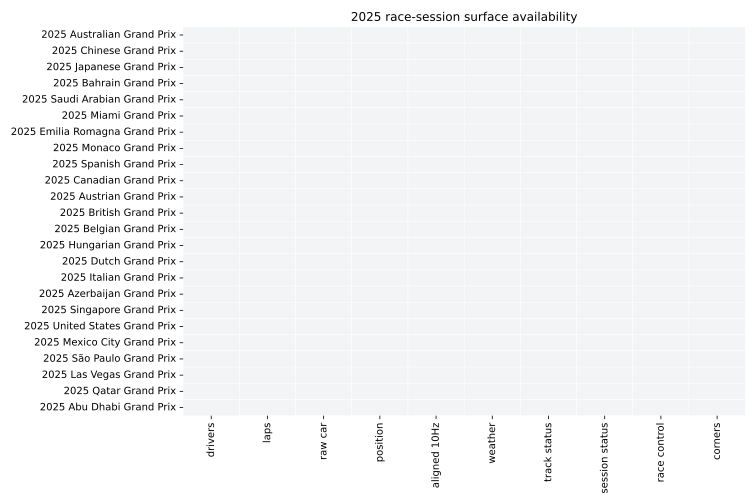

artifacts/2025-race-database-surface-eda/figures/surface_issue_counts.svg


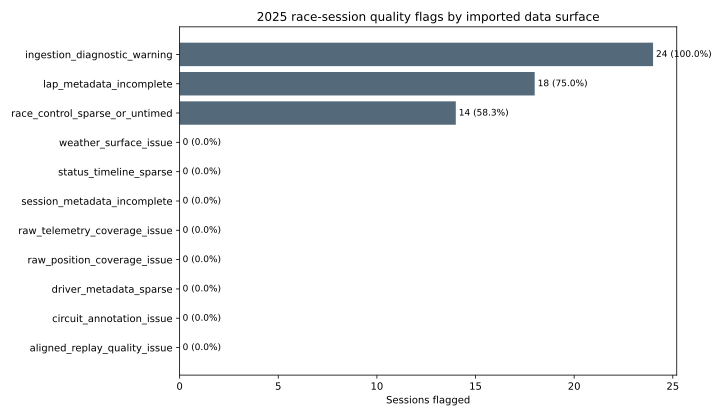

artifacts/2025-race-database-surface-eda/figures/context_density_by_session.svg


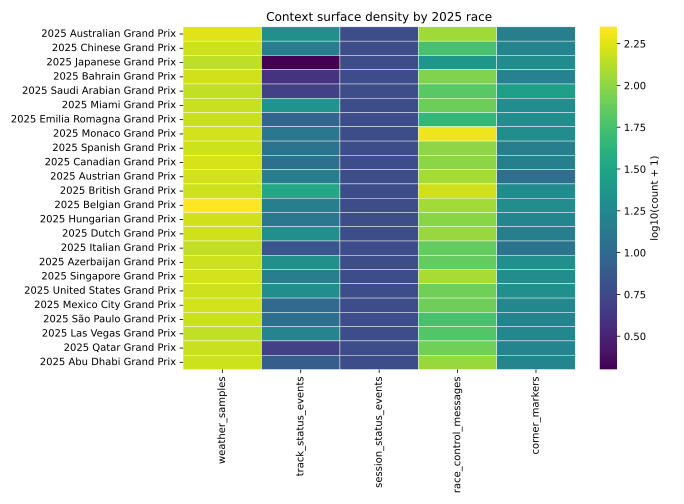

artifacts/2025-race-database-surface-eda/figures/ingestion_frequency_by_stream.svg


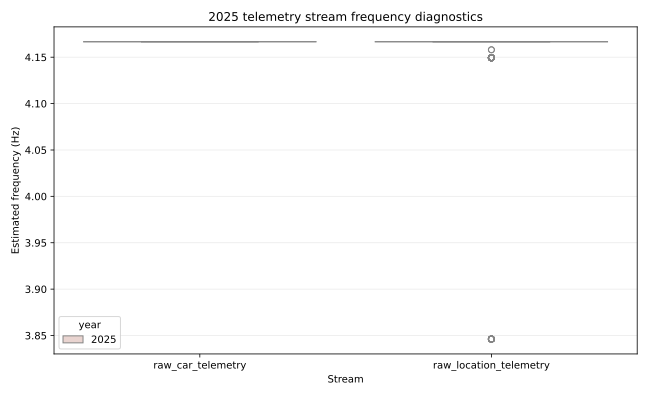

artifacts/2025-race-database-surface-eda/figures/race_control_category_mix.svg


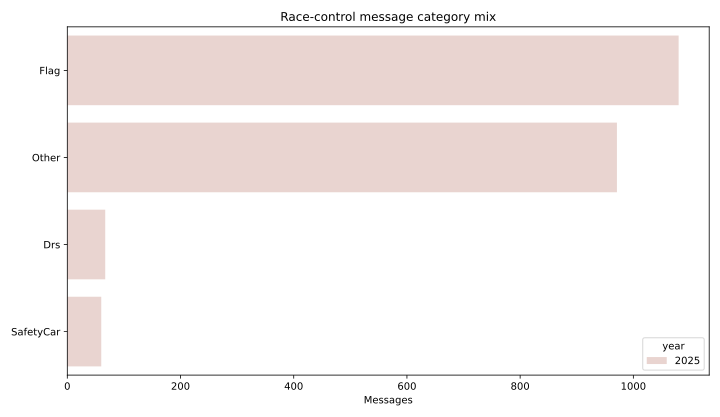

artifacts/2025-race-database-surface-eda/figures/aligned_driver_non_ok_heatmap.svg


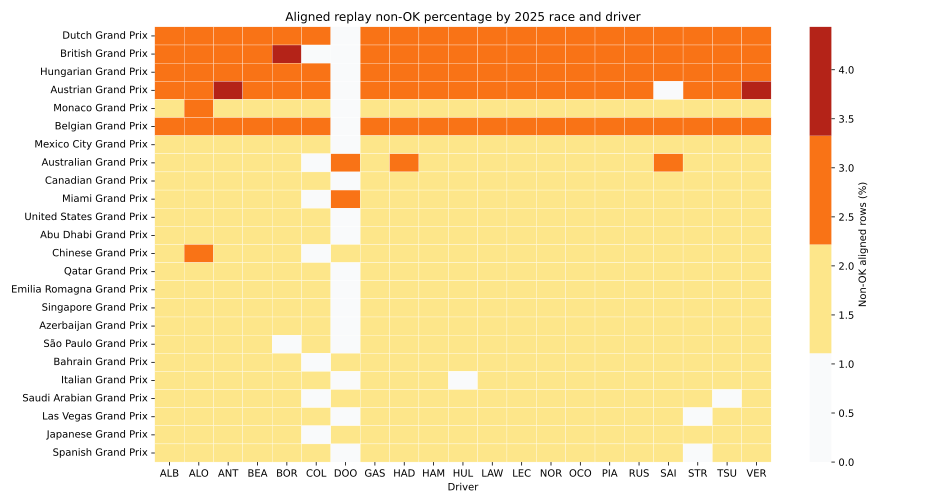

artifacts/2025-race-database-surface-eda/figures/aligned_quality_replay_strips.svg


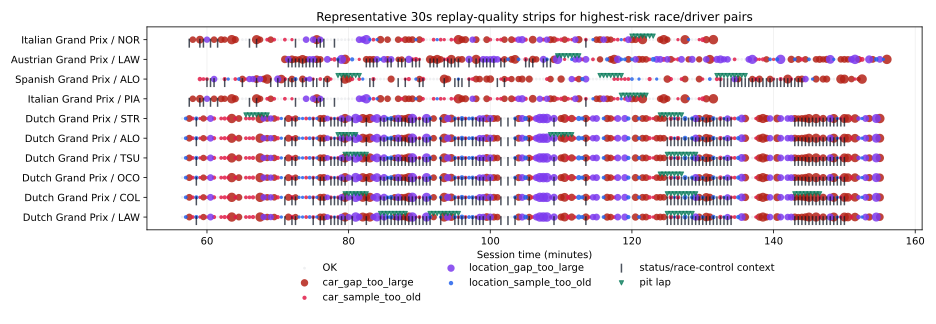

artifacts/2025-race-database-surface-eda/figures/aligned_context_overlap.svg


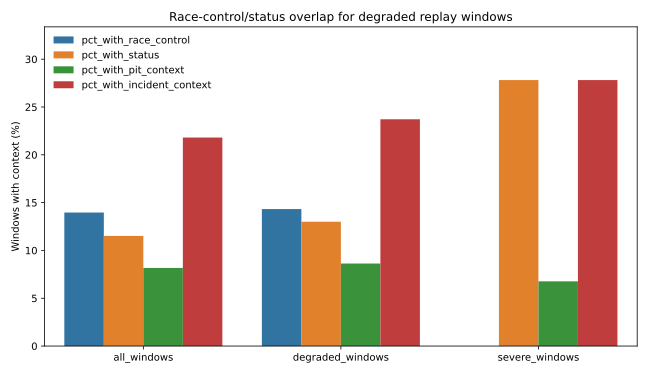

artifacts/2025-race-database-surface-eda/figures/surface_active_coverage_heatmap.svg


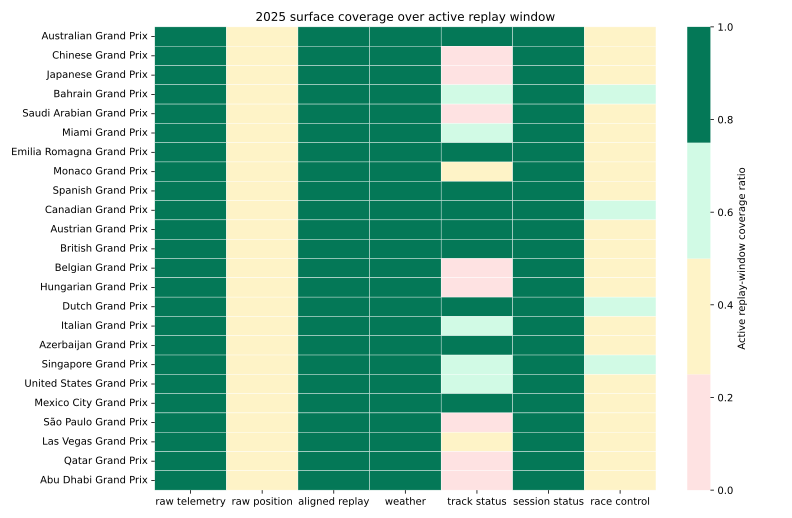

artifacts/2025-race-database-surface-eda/figures/surface_coverage_windows.svg


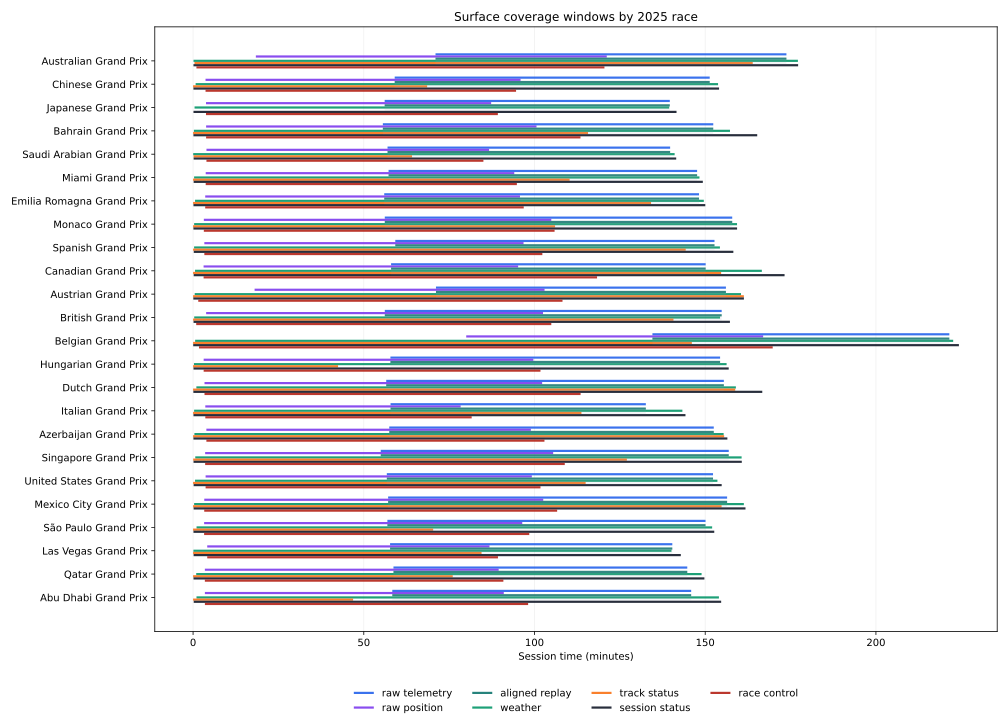

artifacts/2025-race-database-surface-eda/figures/race_control_taxonomy_mix.svg


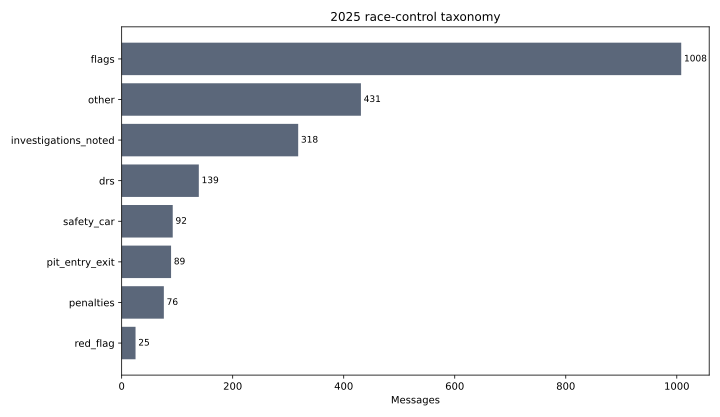

artifacts/2025-race-database-surface-eda/figures/status_timeline_strips.svg


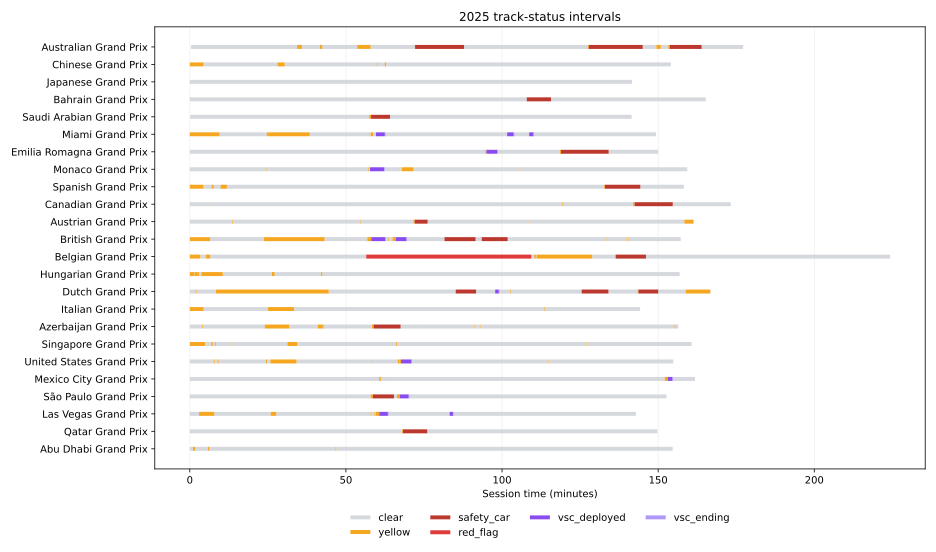

artifacts/2025-race-database-surface-eda/figures/weather_cadence_jumps.svg


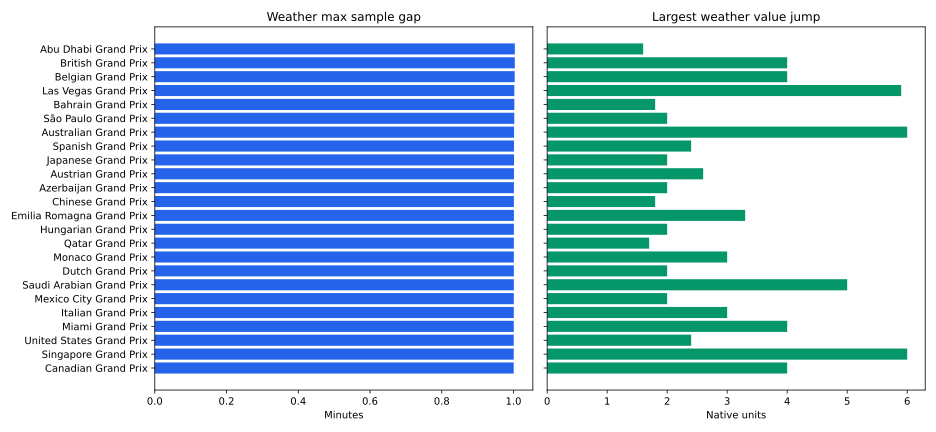

artifacts/2025-race-database-surface-eda/figures/context_timeline_density.svg


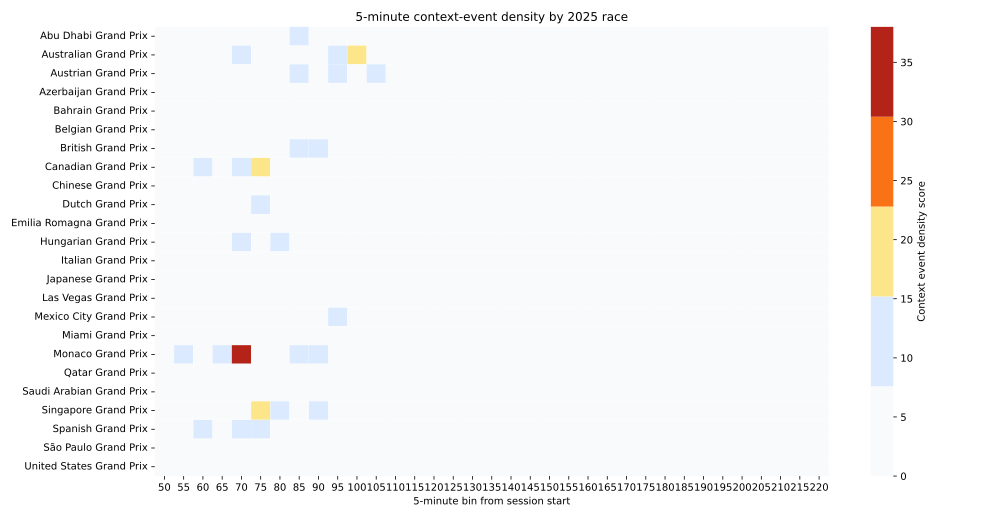

artifacts/2025-race-database-surface-eda/figures/product_readiness_dashboard.svg


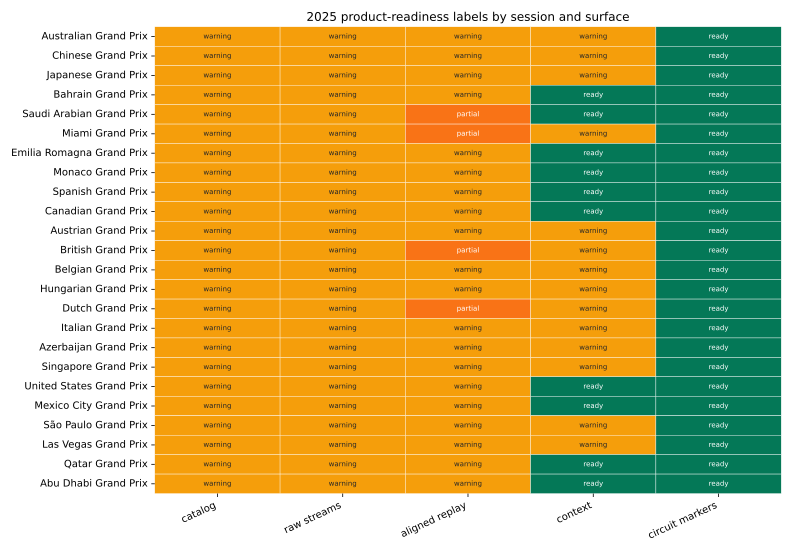

artifacts/2025-race-database-surface-eda/figures/product_recommendation_summary.svg


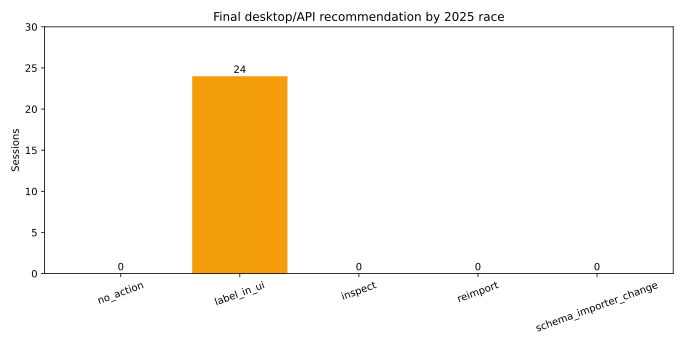

artifacts/2025-race-database-surface-eda/figures/circuit_marker_quality_summary.svg


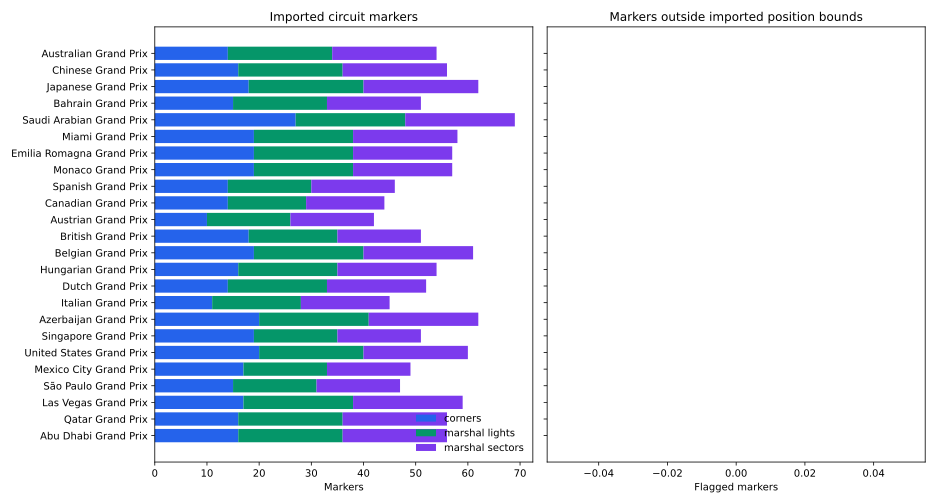

artifacts/2025-race-database-surface-eda/figures/circuit_marker_overlay_examples.svg


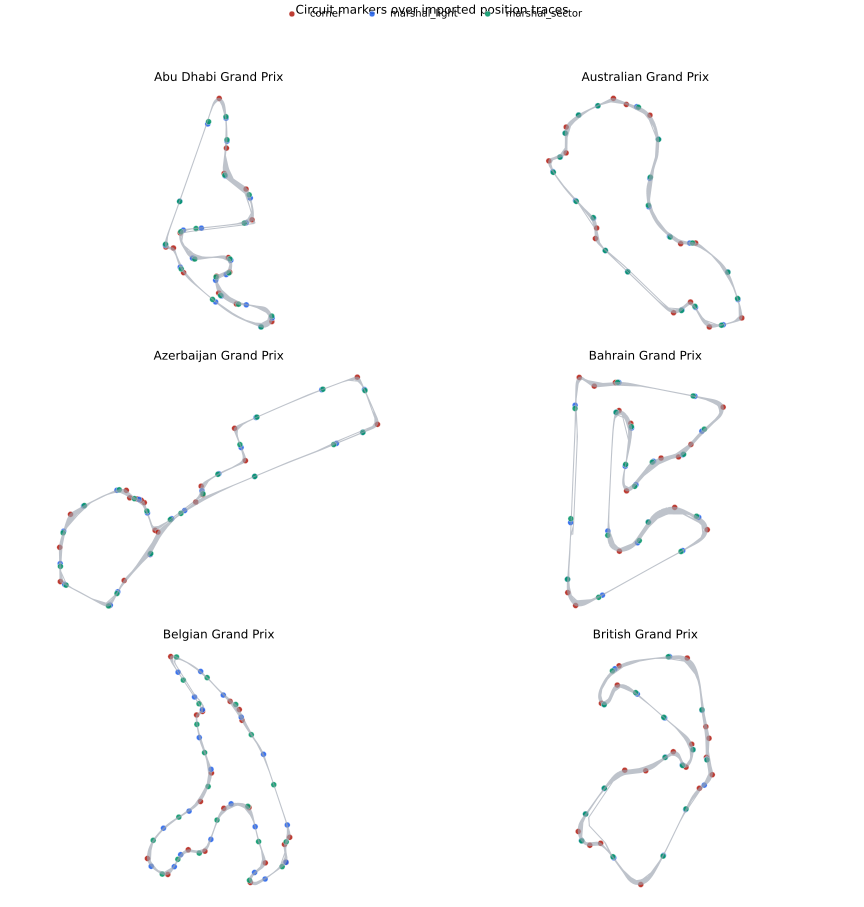

artifacts/2025-race-database-surface-eda/figures/weather_trend_panels.svg


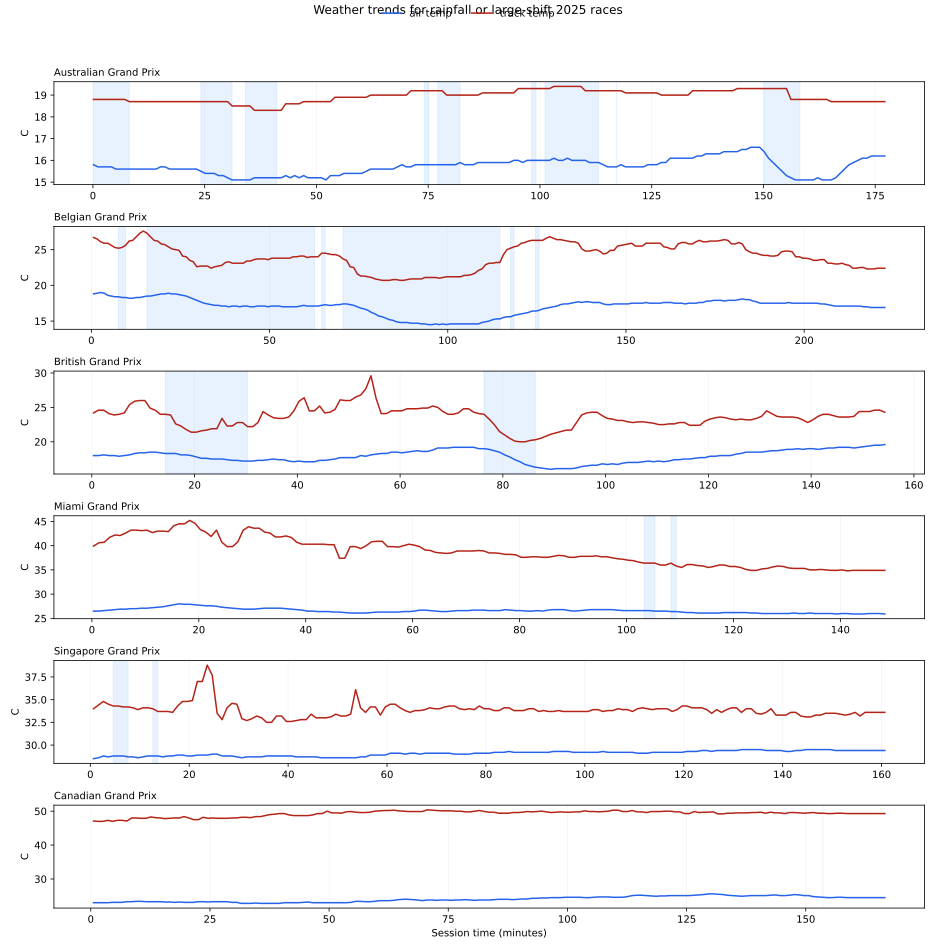

artifacts/2025-race-database-surface-eda/figures/race_control_text_clusters.svg


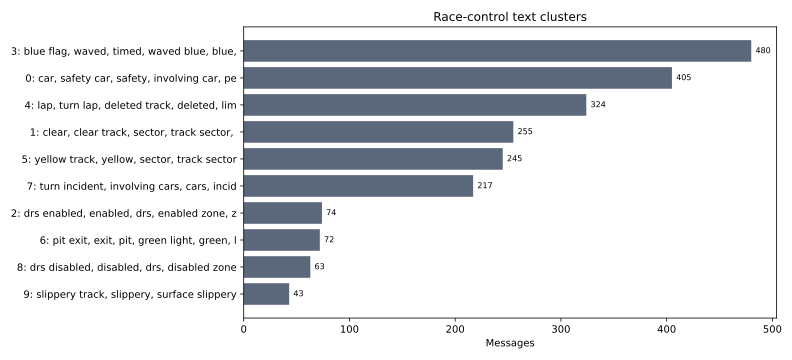

In [15]:
from IPython.display import SVG, display

for path in result["figure_paths"]:
    print(path.relative_to(REPO_ROOT))
    display(SVG(filename=str(path)))


## Outputs

Primary outputs:

- `docs/data-quality/2025-race-database-surface-eda-summary.md`
- `artifacts/2025-race-database-surface-eda/skrub_2025_race_database_surface_report.html`
- `artifacts/2025-race-database-surface-eda/tables/*.csv`
- `artifacts/2025-race-database-surface-eda/tables/session_surface_quality.parquet`
- `artifacts/2025-race-database-surface-eda/tables/aligned_quality_windows_30s.parquet`
- `artifacts/2025-race-database-surface-eda/tables/desktop_replay_quality_watchlist.parquet`
- `artifacts/2025-race-database-surface-eda/tables/session_duration_coverage.parquet`
- `artifacts/2025-race-database-surface-eda/tables/session_surface_coverage_windows.parquet`
- `artifacts/2025-race-database-surface-eda/tables/race_control_messages_classified.parquet`
- `artifacts/2025-race-database-surface-eda/tables/context_timeline_bins_5min.parquet`
- `artifacts/2025-race-database-surface-eda/tables/product_readiness.parquet`
- `artifacts/2025-race-database-surface-eda/tables/circuit_marker_quality.csv`
- `artifacts/2025-race-database-surface-eda/tables/race_control_text_cluster_summary.csv`
- `artifacts/2025-race-database-surface-eda/figures/*.svg`

Command-line rerun:

```bash
.venv/bin/python notebooks/database_surface_quality_support.py
```

The next useful iteration is raw stream diagnostic severity and
deciding whether these offline readiness labels should be persisted
or only surfaced as generated QA artifacts.
